# Estudo da estrutura dos arquivos de IA extraídos

Este notebook tem como objetivo analisar a estrutura resultante da extração de cabeçalhos dos arquivos de contexto de IA (`AGENTS.md`, `CLAUDE.md`, etc.), gerando estatísticas sobre a hierarquia e os termos mais comuns antes da classificação semântica.

## Importação de bibliotecas e configuração

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [9]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## Carregamento dos dados

O arquivo analisado é o `structure_analysis.csv`, gerado pelo script `extract_content_structure.py`.

In [10]:
DATA_PATH = "../data/content_analysis/structure_analysis.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Total de registros: {len(df)}")
    print(f"Total de repositórios únicos: {df['repo'].nunique()}")
    display(df.head())
else:
    print(f"Arquivo {DATA_PATH} não encontrado. Execute o script de extração primeiro.")
    df = pd.DataFrame()

Total de registros: 8129
Total de repositórios únicos: 266


,repo,file_type,level,title_original,title_normalized
0,elastic/elasticsearch,AGENTS.md,1,Elasticsearch,elasticsearch
1,elastic/elasticsearch,AGENTS.md,2,Toolchain Snapshot,toolchain snapshot
2,elastic/elasticsearch,AGENTS.md,2,Build & Run Commands,build run commands
3,elastic/elasticsearch,AGENTS.md,2,Verification & Lint Tasks,verification lint tasks
4,elastic/elasticsearch,AGENTS.md,2,Project Structure,project structure


## Análise de hierarquia

Verifica a distribuição dos níveis de cabeçalho (`#`, `##`, `###`). Níveis mais altos (2 e 3) geralmente indicam instruções mais detalhadas.

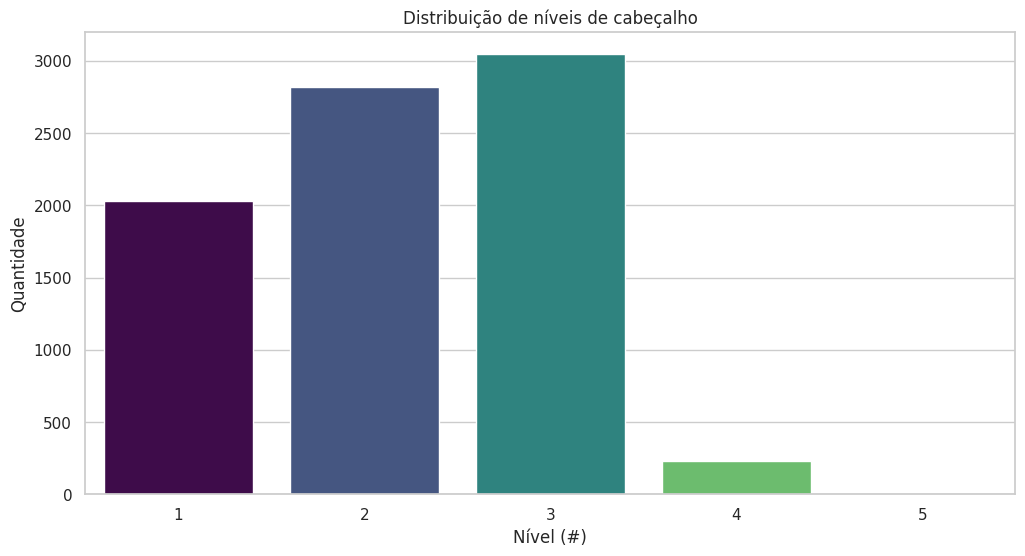

Porcentagem por nível:
level
3    37.458482
2    34.653709
1    24.972321
4     2.866281
5     0.049207
Name: proportion, dtype: float64


In [11]:
if not df.empty:
    level_counts = df['level'].value_counts().sort_index()
    sns.countplot(data=df, x='level', hue='level', palette='viridis', legend=False)
    
    plt.title("Distribuição de níveis de cabeçalho")
    plt.xlabel("Nível (#)")
    plt.ylabel("Quantidade")
    plt.show()
    
    print("Porcentagem por nível:")
    print(df['level'].value_counts(normalize=True) * 100)

## 4. Distribuição por tipo de arquivo

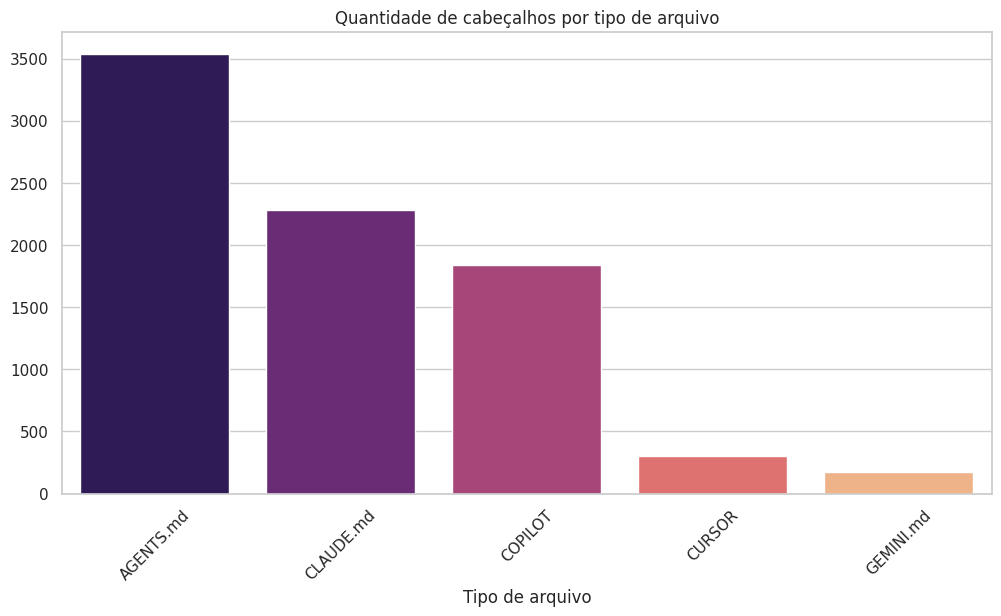

In [15]:
if not df.empty:
    file_counts = df['file_type'].value_counts()
    sns.barplot(x=file_counts.index, y=file_counts.values, hue=file_counts.index, palette='magma', legend=False)
    plt.title("Quantidade de cabeçalhos por tipo de arquivo")
    plt.xlabel("Tipo de arquivo")
    plt.xticks(rotation=45)
    plt.show()

## Termos mais frequentes (headings puros)

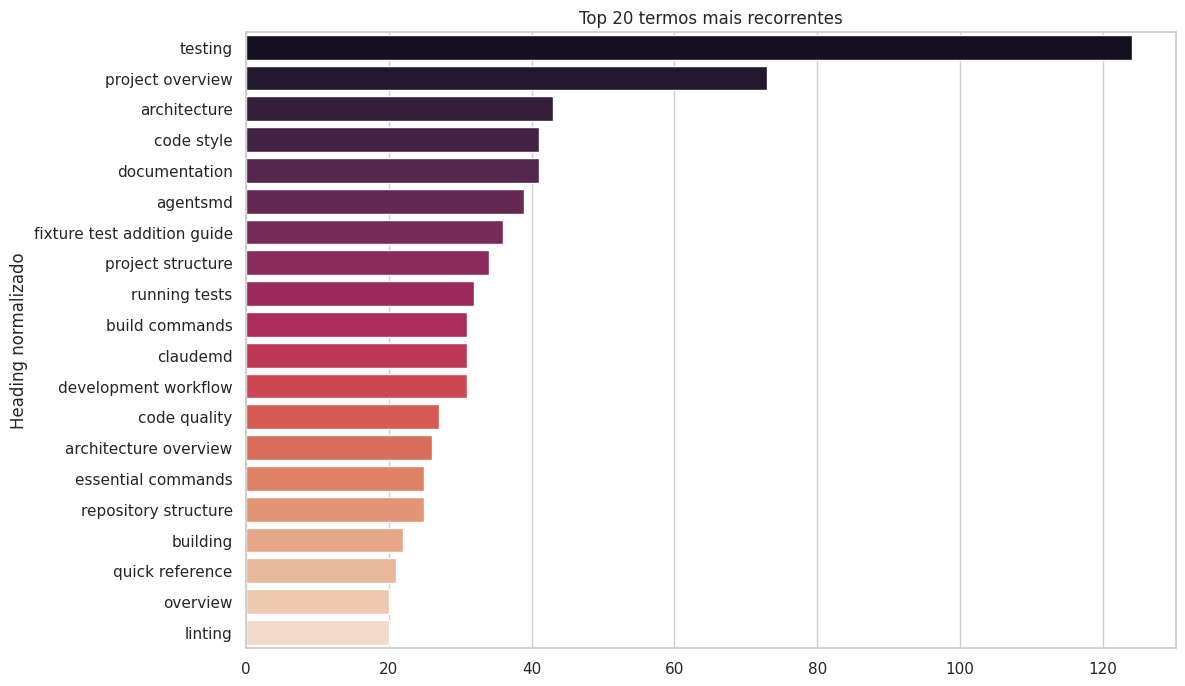

In [20]:
if not df.empty:
    top_titles = df['title_normalized'].value_counts().head(20)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_titles.values, y=top_titles.index, hue=top_titles.index, palette='rocket', legend=False)
    plt.title("Top 20 termos mais recorrentes")
    plt.ylabel("Heading normalizado")
    plt.show()